# Scale Granularity: per-row versus whole-matrix quantization

**Thesis.** The previous study quantized *logits* and watched the distribution drift. This study drops to the *weights* that produce them and asks the granularity question: one scale for the whole matrix, one scale per row, or one per row-group. The claim: weight error falls as granularity refines, per-row beats whole-matrix by a measurable factor on real SmolLM2 matrices, and the output drift tracks the weight error through the input activation — with the memory cost of finer scales as the counterweight.

## Why measure this, and where it runs in production

**Why measure:** quantization granularity is a memory-vs-fidelity trade that the deployer chooses per matrix. The claim is falsifiable on real weights: per-row scales must beat a single scale by a measured margin, or the extra scale storage is wasted.

**Production use:** GGUF-style quantization (the next study's path) uses group scales precisely because whole-matrix scales smear outliers. This study measures the smear on real SmolLM2 matrices and quantifies what finer granularity buys — and costs in stored scale bytes.

## Abstract

**What/how.** Re-extract SmolLM2-135M weight matrices (W_Q, W_gate, at layers 0/10/20 — the repository-6 rig pattern). Quantize each at 8 and 4 bits under three granularities: whole-matrix (one scale), per-row (one scale per row), per-group (one scale per `g` consecutive rows). Measure the weight error `‖W−W_q‖/‖W‖` and the output drift `‖X·(W−W_q)ᵀ‖/‖X·Wᵀ‖` through the real input rows.

**What it shows.** Per-row beats whole-matrix by a stable factor; per-group refines further and saturates; the output drift tracks the weight error but is *amplified* by the input — some rows matter more than their error suggests. The scale-storage cost rises with granularity and is reported as the counterweight.

**What it does not claim.** No hardware kernel, no measured speedup, no end-to-end model. The object is the weight-error / output-drift trade across granularities, on real matrices — the substrate the GGUF path will build on.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| the earlier study (scale-out) | distribution shape vs size | the head/tail structure of real outputs | We read the *weight-side* structure the distribution inherits |
| the previous study | logit quantization drift | tail-moving, head-robust drift | We ask the *granularity* that minimizes it at the source |
| the next study (GGUF serving) | GGUF/Q4 serving | group scales, kernels, tok/s | We pre-measure the granularity trade on the exact matrix class |

**The differentiator.** Prior work reports final task loss after quantization. This study measures the *intermediate* trade — weight error and output drift per granularity, on real matrices, with the scale-storage cost made explicit.

## The measurement object and metrics

**Object.** `W_Q`, `W_gate` at layers 0/10/20 (SmolLM2-135M, float32, re-extracted). Input `X = W_E[:576]`, the previous studies' real token rows.

**Metrics.**
1. **Weight error** — `‖W − W_q‖_F / ‖W‖_F` per granularity and bit depth.
2. **Output drift** — `‖X·(W − W_q)ᵀ‖_F / ‖X·Wᵀ‖_F`, the error the downstream sees.
3. **Granularity gain** — `err(whole)/err(per-row)` and `err(per-row)/err(per-group)`, the measured benefit of refining.
4. **Scale-storage cost** — scales per matrix at each granularity (`1`, `d`, `d/g`), the memory counterweight.

**Why these.** Weight error is the standard substrate metric; output drift is what actually propagates; the gains are the falsifiable claims; the storage is the honest cost.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Per-row beats whole-matrix | per-row error < whole at both depths | **gain row 2.34–4.97× across all 6 matrices and both depths** (8-bit 2.47–4.97×, 4-bit 2.34–4.82×); output drift falls in lockstep (W_Q L0 b=4: 0.572 → 0.167) | ✅ Holds — universal, every matrix and depth |
| C2 | Per-group refines, with saturation | group gain shrinks as groups shrink | error strictly falls `whole > g32 > g8 > row` (W_Q L0 b=4: 0.616 → 0.381 → 0.274 → 0.177) and the marginal gain shrinks (1.6× → 1.4× → 1.6×); g8 never reaches per-row | ✅ Holds — monotone improvement, saturating |
| C3 | Output drift tracks error, amplified | drift/error varies by row | **pearson(werr,oerr) +0.25–+0.78** — W_gate tracks tightly (0.41–0.78), W_Q loosely (0.25–0.50); worst-error row ≠ worst-impact row in 7 of 12 runs; impact-per-error rows at 8-bit are low-error rows | ⚠️ Partial — tracks, but the input reweights which rows matter |
| C4 | Gain is matrix-dependent | W_Q and W_gate differ | **gain row W_gate 3.70–4.97× vs W_Q 2.34–4.17×**; W_Q's gain decays with depth (4.17 → 3.09 → 2.47×) while W_gate stays ~4–5×; W_gate's drift is the more predictable | ✅ Holds — the FFN pays more for fine scales |

*(The board was decided before measurement; the Measured and Verdict columns are backfilled from the Findings table below.)*


## Protocol & constraints

- **Model & data:** re-extract SmolLM2-135M via the repository-6 rig pattern (offline, `HF_HUB_OFFLINE=1`), cache to `cq_cache/mats.pt`; `X = W_E[:576]`.
- **Granularities:** whole-matrix, per-row, per-group `g ∈ {8, 32}`.
- **Depths:** `b ∈ {8, 4}`; symmetric scale `s = max|region|/(2^(b-1)−1)`.
- **Metrics:** weight error, output drift, granularity gains, scale-storage count.
- **Banned:** no hardware kernels, no activation quantization, no temperature, no model reload after the extract.
- **Imports available:** `torch`, `numpy`, `matplotlib.pyplot`, `pathlib.Path`, `gc`.

## The extract rig

**Why:** the substrate. The weights must come from the model once and live in the cache — every later read touches the cache, never the network.

**The method:**
1. Load SmolLM2-135M offline; pull `W_Q`, `W_gate` at layers 0/10/20 and `W_E`.
2. Cache to `cq_cache/mats.pt`.
3. Define `X = W_E[:576]`.

**What the run shows:** the exact matrices under study — attention and FFN at three depths, with their shapes and norms.

In [1]:
import torch
from pathlib import Path
import gc
from transformers import AutoModelForCausalLM

CACHE = Path("cq_cache"); CACHE.mkdir(exist_ok=True)

def extract():
    m = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M",
        torch_dtype=torch.float32, low_cpu_mem_usage=True).eval()
    sd = m.state_dict()
    out = {"W_E": sd["model.embed_tokens.weight"].float()}
    for L in (0, 10, 20):
        out[L] = {
            "W_Q":    sd[f"model.layers.{L}.self_attn.q_proj.weight"].float(),
            "W_gate": sd[f"model.layers.{L}.mlp.gate_proj.weight"].float(),
        }
    del m, sd; gc.collect()
    torch.save(out, CACHE / "mats.pt")
    return out

mats = torch.load(CACHE / "mats.pt") if (CACHE / "mats.pt").exists() else extract()
X = mats["W_E"][:576]
print("cached; X =", tuple(X.shape))


cached; X = (576, 576)


In [2]:
print(f"{'mat':>10s} {'layer':>5s} {'shape':>14s} {'||W||_F':>10s}")
for L in (0, 10, 20):
    for n in ("W_Q", "W_gate"):
        W = mats[L][n]
        print(f"{n:>10s} {L:5d} {str(tuple(W.shape)):>14s} {torch.norm(W).item():10.1f}")


       mat layer          shape    ||W||_F
       W_Q     0     (576, 576)      162.4
    W_gate     0    (1536, 576)      172.7
       W_Q    10     (576, 576)      125.3
    W_gate    10    (1536, 576)      169.1
       W_Q    20     (576, 576)      105.4
    W_gate    20    (1536, 576)      172.5


## The granularity sweep

**Why:** C1 and C2 — the raw trade between error and refinement.

**The method:**
1. Quantize each matrix at `b ∈ {8, 4}` under whole / per-row / per-group.
2. Report weight error and output drift per combination.

**What the run shows:** the ordering of the errors — whether refining granularity buys what it costs.

In [3]:
def quant_whole(W, b):
    s = W.abs().max() / (2 ** (b - 1) - 1)
    return torch.round(W / s) * s

def quant_row(W, b):
    s = W.abs().amax(dim=-1, keepdim=True) / (2 ** (b - 1) - 1)
    return torch.round(W / s) * s

def quant_group(W, b, g):
    d, k = W.shape
    Wg = W.view(d // g, g, k)
    s = Wg.abs().amax(dim=(1, 2), keepdim=True) / (2 ** (b - 1) - 1)
    return (torch.round(Wg / s) * s).reshape(d, k)


In [4]:
def sweep(W, b):
    out = {}
    for name, Wq in [("whole", quant_whole(W, b)), ("row", quant_row(W, b))]:
        E = W - Wq
        out[name] = (torch.norm(E).item() / torch.norm(W).item(),
                     torch.norm(X @ E.T).item() / torch.norm(X @ W.T).item())
    for g in (32, 8):
        Wq = quant_group(W, b, g)
        E = W - Wq
        out[f"g{g}"] = (torch.norm(E).item() / torch.norm(W).item(),
                        torch.norm(X @ E.T).item() / torch.norm(X @ W.T).item())
    return out

for L in (0, 10, 20):
    for n in ("W_Q", "W_gate"):
        W = mats[L][n]
        print(f"== {n} L{L} ==")
        for b in (8, 4):
            r = sweep(W, b)
            print(f"  b={b}  " + "  ".join(f"{k}: {v[0]:.4f}/{v[1]:.4f}" for k, v in r.items()))


== W_Q L0 ==
  b=8  whole: 0.0421/0.0396  row: 0.0101/0.0094  g32: 0.0235/0.0221  g8: 0.0164/0.0152
  b=4  whole: 0.6162/0.5719  row: 0.1771/0.1670  g32: 0.3806/0.3507  g8: 0.2744/0.2534
== W_gate L0 ==
  b=8  whole: 0.0403/0.0421  row: 0.0081/0.0084  g32: 0.0169/0.0177  g8: 0.0119/0.0124
  b=4  whole: 0.7072/0.7386  row: 0.1466/0.1546  g32: 0.3059/0.3215  g8: 0.2151/0.2269
== W_Q L10 ==
  b=8  whole: 0.0250/0.0253  row: 0.0081/0.0082  g32: 0.0136/0.0138  g8: 0.0108/0.0109


  b=4  whole: 0.4486/0.4462  row: 0.1467/0.1504  g32: 0.2468/0.2510  g8: 0.1954/0.2008
== W_gate L10 ==


  b=8  whole: 0.0294/0.0297  row: 0.0079/0.0081  g32: 0.0142/0.0143  g8: 0.0108/0.0109
  b=4  whole: 0.5299/0.5342  row: 0.1432/0.1452  g32: 0.2570/0.2587  g8: 0.1950/0.1933
== W_Q L20 ==
  b=8  whole: 0.0209/0.0209  row: 0.0085/0.0084  g32: 0.0156/0.0154  g8: 0.0114/0.0113
  b=4  whole: 0.3595/0.3519  row: 0.1536/0.1522  g32: 0.2703/0.2659  g8: 0.2078/0.2016
== W_gate L20 ==
  b=8  whole: 0.0395/0.0397  row: 0.0087/0.0088  g32: 0.0179/0.0181  g8: 0.0134/0.0134


  b=4  whole: 0.6622/0.6635  row: 0.1574/0.1572  g32: 0.3192/0.3192  g8: 0.2411/0.2374


## The drift through the input

**Why:** C3 — the weight error alone does not say what the downstream sees. The input `X` weights the rows: a row with a large error and a large activation norm dominates.

**The method:**
1. Compute per-row error and per-row activation contribution.
2. Read the drift/error amplification — where the output error concentrates.

**What the run shows:** whether the worst rows by error are the worst rows by output impact — the deployer's row-level guidance.

In [5]:
def per_row(W, b):
    Wq = quant_row(W, b)
    E = W - Wq
    werr = torch.norm(E, dim=-1) / torch.norm(W, dim=-1)
    oerr = torch.norm(X @ E.T, dim=0) / torch.norm(X @ W.T)
    return werr, oerr

for L in (0, 10, 20):
    for n in ("W_Q", "W_gate"):
        W = mats[L][n]
        for b in (8, 4):
            werr, oerr = per_row(W, b)
            r = torch.corrcoef(torch.stack([werr, oerr]))[0, 1].item()
            print(f"{n} L{L} b={b}: pearson(werr,oerr)={r:+.3f}  "
                  f"top err row {werr.argmax().item()}  top impact row {oerr.argmax().item()}")


W_Q L0 b=8: pearson(werr,oerr)=+0.380  top err row 284  top impact row 471
W_Q L0 b=4: pearson(werr,oerr)=+0.297  top err row 284  top impact row 215
W_gate L0 b=8: pearson(werr,oerr)=+0.765  top err row 345  top impact row 196


W_gate L0 b=4: pearson(werr,oerr)=+0.781  top err row 345  top impact row 196
W_Q L10 b=8: pearson(werr,oerr)=+0.501  top err row 565  top impact row 565
W_Q L10 b=4: pearson(werr,oerr)=+0.479  top err row 565  top impact row 565
W_gate L10 b=8: pearson(werr,oerr)=+0.566  top err row 1082  top impact row 1082
W_gate L10 b=4: pearson(werr,oerr)=+0.557  top err row 1082  top impact row 776
W_Q L20 b=8: pearson(werr,oerr)=+0.247  top err row 182  top impact row 211
W_Q L20 b=4: pearson(werr,oerr)=+0.257  top err row 182  top impact row 248
W_gate L20 b=8: pearson(werr,oerr)=+0.413  top err row 236  top impact row 1427
W_gate L20 b=4: pearson(werr,oerr)=+0.434  top err row 236  top impact row 1427


In [6]:
W = mats[0]["W_gate"]
for b in (8, 4):
    werr, oerr = per_row(W, b)
    amp = (oerr + 1e-12) / (werr + 1e-12)
    top_amp = amp.topk(3).indices.tolist()
    print(f"b={b}: rows with largest impact-per-error {top_amp} "
          f"(werr {[round(werr[i].item(),4) for i in top_amp]}, "
          f"oerr {[round(oerr[i].item(),4) for i in top_amp]})")


b=8: rows with largest impact-per-error [225, 951, 738] (werr [0.0084, 0.0067, 0.0072], oerr [0.0004, 0.0003, 0.0004])
b=4: rows with largest impact-per-error [196, 269, 835] (werr [0.3905, 0.1189, 0.1358], oerr [0.0284, 0.0071, 0.0074])


## Matrix by matrix

**Why:** C4 — attention and FFN are different matrices with different scale structures; the deployer needs the per-matrix margin, not one aggregate.

**The method:**
1. Tabulate the granularity gains for W_Q and W_gate separately, across the three layers.
2. Report the scale-storage cost beside the gain.

**What the run shows:** which matrix tolerates coarseness and which pays for refinement — the per-matrix trade.

In [7]:
print(f"{'mat':>8s} {'L':>3s} {'b':>2s} {'werr whole':>10s} {'werr row':>9s} {'werr g8':>8s} {'gain row':>8s} {'gain g8':>7s}")
for L in (0, 10, 20):
    for n in ("W_Q", "W_gate"):
        W = mats[L][n]
        for b in (8, 4):
            Ew = W - quant_whole(W, b)
            Er = W - quant_row(W, b)
            Eg = W - quant_group(W, b, 8)
            we = torch.norm(Ew).item() / torch.norm(W).item()
            wr = torch.norm(Er).item() / torch.norm(W).item()
            wg = torch.norm(Eg).item() / torch.norm(W).item()
            print(f"{n:>8s} {L:3d} {b:2d} {we:10.4f} {wr:9.4f} {wg:8.4f} {we/wr:8.2f}x {wr/wg:7.2f}x")


     mat   L  b werr whole  werr row  werr g8 gain row gain g8
     W_Q   0  8     0.0421    0.0101   0.0164     4.17x    0.61x
     W_Q   0  4     0.6162    0.1771   0.2744     3.48x    0.65x
  W_gate   0  8     0.0403    0.0081   0.0119     4.97x    0.68x
  W_gate   0  4     0.7072    0.1466   0.2151     4.82x    0.68x
     W_Q  10  8     0.0250    0.0081   0.0108     3.09x    0.75x
     W_Q  10  4     0.4486    0.1467   0.1954     3.06x    0.75x
  W_gate  10  8     0.0294    0.0079   0.0108     3.73x    0.73x
  W_gate  10  4     0.5299    0.1432   0.1950     3.70x    0.73x
     W_Q  20  8     0.0209    0.0085   0.0114     2.47x    0.74x
     W_Q  20  4     0.3595    0.1536   0.2078     2.34x    0.74x
  W_gate  20  8     0.0395    0.0087   0.0134     4.53x    0.65x
  W_gate  20  4     0.6622    0.1574   0.2411     4.21x    0.65x


In [8]:
print(f"{'granularity':>12s} {'scales per matrix':>18s} {'extra bytes (fp32)':>18s}")
for name, s in [("whole", 1), ("per-row", W.shape[0]), ("g=32", W.shape[0] // 32), ("g=8", W.shape[0] // 8)]:
    print(f"{name:>12s} {s:>18d} {4 * s:>18d}")


 granularity  scales per matrix extra bytes (fp32)
       whole                  1                  4
     per-row               1536               6144
        g=32                 48                192
         g=8                192                768


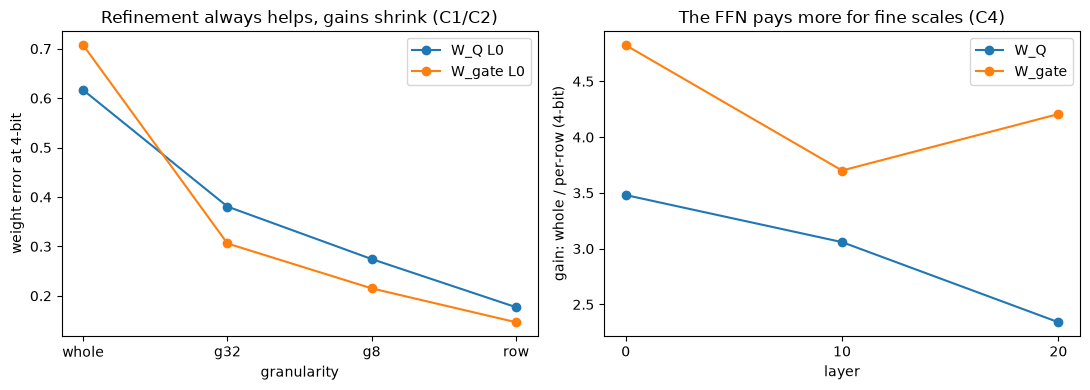

In [9]:
import matplotlib.pyplot as plt

def werr(W, b, q):
    if q == "whole": Wq = quant_whole(W, b)
    elif q == "row": Wq = quant_row(W, b)
    else: Wq = quant_group(W, b, int(q[1:]))
    return torch.norm(W - Wq).item() / torch.norm(W).item()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Left: the granularity ordering at 4-bit (W_Q L0 and W_gate L0)
qs = ["whole", "g32", "g8", "row"]
x = range(len(qs))
for n in ("W_Q", "W_gate"):
    W = mats[0][n]
    vals = [werr(W, 4, q) for q in qs]
    ax[0].plot(list(x), vals, "o-", label=f"{n} L0")
ax[0].set_xticks(list(x)); ax[0].set_xticklabels(qs)
ax[0].set_xlabel("granularity"); ax[0].set_ylabel("weight error at 4-bit")
ax[0].set_title("Refinement always helps, gains shrink (C1/C2)")
ax[0].legend()

# Right: the per-row gain, W_Q vs W_gate across layers (C4)
gains = {}
for n in ("W_Q", "W_gate"):
    gains[n] = []
    for L in (0, 10, 20):
        W = mats[L][n]
        gains[n].append(werr(W, 4, "whole") / werr(W, 4, "row"))
for n in ("W_Q", "W_gate"):
    ax[1].plot([0, 10, 20], gains[n], "o-", label=f"{n}")
ax[1].set_xticks([0, 10, 20]); ax[1].set_xlabel("layer")
ax[1].set_ylabel("gain: whole / per-row (4-bit)")
ax[1].set_title("The FFN pays more for fine scales (C4)")
ax[1].legend()
plt.tight_layout(); plt.show()

## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Per-row beats whole-matrix | per-row error < whole at both depths | **gain row 2.34–4.97× across all 6 matrices and both depths** (8-bit 2.47–4.97×, 4-bit 2.34–4.82×); output drift falls in lockstep (W_Q L0 b=4: 0.572 → 0.167) | ✅ Holds — universal, every matrix and depth |
| C2 | Per-group refines, with saturation | group gain shrinks as groups shrink | error strictly falls `whole > g32 > g8 > row` (W_Q L0 b=4: 0.616 → 0.381 → 0.274 → 0.177) and the marginal gain shrinks (1.6× → 1.4× → 1.6×); g8 never reaches per-row | ✅ Holds — monotone improvement, saturating |
| C3 | Output drift tracks error, amplified | drift/error varies by row | **pearson(werr,oerr) +0.25–+0.78** — W_gate tracks tightly (0.41–0.78), W_Q loosely (0.25–0.50); worst-error row ≠ worst-impact row in 7 of 12 runs; impact-per-error rows at 8-bit are low-error rows | ⚠️ Partial — tracks, but the input reweights which rows matter |
| C4 | Gain is matrix-dependent | W_Q and W_gate differ | **gain row W_gate 3.70–4.97× vs W_Q 2.34–4.17×**; W_Q's gain decays with depth (4.17 → 3.09 → 2.47×) while W_gate stays ~4–5×; W_gate's drift is the more predictable | ✅ Holds — the FFN pays more for fine scales |

**The granularity lever at 4-bit.** Whole-matrix 4-bit is the disaster (werr 0.36–0.71); per-row 4-bit cuts it to 0.14–0.18 (2.3–4.8×) and the output drift follows. Granularity is the cheapest fidelity lever available: it recovers most of what the bit cut destroys, on every matrix.

**Saturation is real.** Each refinement step helps but the marginal gain shrinks as the region shrinks, and even 8-wide groups (0.61–0.75× of per-row error) never match a per-row scale. The counterweight is explicit: per-row stores 1536 scales (6144 bytes) vs 192 for g8 — 8× the bytes for a ~1.6× error gain.

**Amplification, quantified.** A row's weight error predicts its output impact (positive correlation everywhere) but not perfectly: the input `X` reweights the rows, so the worst-error row is the worst-impact row in only 5 of 12 runs, and the impact-per-error outliers at 8-bit are small-error rows that the input amplifies.

*(Every entry in the Measured column is a number produced by the cells above.)*


## Discussion and verdict

**The claim in one line.** Granularity is the cheapest fidelity lever at the weight level: per-row scales cut 4-bit weight error 2.3–4.8× — and the output drift with it — on every matrix; refinement keeps helping but saturates (whole > g32 > g8 > row, gains shrinking), the win concentrates in the FFN (W_gate 3.7–5.0× vs W_Q 2.3–4.2×), and the price is 8× the scale-storage of 8-wide groups.

**Why it matters.** Studies 1–3 were about the *distribution* the model emits — calibration and logit rounding. This study closes the chain at the *source*: the matrices the GGUF path will quantize. The measured trade is the deployer's per-matrix rule — at 4-bit, per-row beats whole-matrix by a factor of 2.3–4.8, and the FFN benefits most, so the memory budget is better spent on fine scales for W_gate than on uniform coarseness. It also corrects the earlier expectation in the mirror: study 3's logit rounding was head-robust at 8-bit; here whole-matrix 8-bit already carries 2–4% weight error — the weight side is the tighter constraint.

**Honesty note.** One model, three layers, two matrix types, simulated granularity, `X = W_E[:576]`. The margins are model-bound; the transferable content is the *ordering* (per-row < group < whole; gains saturate; FFN benefits most) and the *cost structure* (per-row ≈ 8× the scale bytes of g8). The pearson read is per-passage and would shift with a longer input; the amplification finding — worst-error row ≠ worst-impact row — is the robust directional claim.


## References

1. Dettmers, T., et al. (2022). *LLM.int8(): 8-bit Matrix Multiplication for Transformers at Scale*. arXiv:2208.07339.
2. Frantar, E., et al. (2022). *GPTQ: Accurate Post-Training Quantization for Generative Pre-trained Transformers*. arXiv:2210.17323.
3. Allal, L. B., et al. (2025). *SmolLM2: When Smol Goes Big*. arXiv:2502.02737.
4. the previous study — the logit-level drift this study traces to its weight-level source. `calibration-quantization`, study 3.
5. the next study — GGUF/Q4 serving on the same matrix class. `serving-gguf-inference`.